In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(data.table)
    library(stringr)
    library(dplyr)
    library(parallel)
    library(glue)
    library(patchwork)
    library(ape)
    library(igraph)
    library(ggtree)
    library(ggpubr)
    library(tidygraph)
    library(ggrepel)
    library(ggtreeExtra)
    library(redeemR)
    library(Seurat)
    library(Signac)
    library(mitodrift)
})
filter = dplyr::filter
options(repr.matrix.max.cols=15, repr.matrix.max.rows=50)
rename = dplyr::rename
R.utils::sourceDirectory(glue('../../R'))

Warning message:
“package ‘data.table’ was built under R version 4.4.3”
Warning message:
“package ‘ggpubr’ was built under R version 4.4.3”
Warning message:
“replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::where’ by ‘dplyr::where’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::melt’ by ‘reshape2::melt’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::dcast’ by ‘reshape2::dcast’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::keep.tip’ by ‘tidytree::keep.tip’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::drop.tip’ by ‘tidytree::drop.tip’ when loading ‘redeemR’”
Warning m

In [3]:
conf_dict = c(
    'MM_BB122' = 0.075,
    'MM_BB094' = 0.075,
    'MM_BB121' = 0.075
)

donors = c('MM_BB094', 'MM_BB121', 'MM_BB122')

phy_trim_all = mclapply(
    donors,
    mc.cores = 3,
    function(donor) {
        phy_annot = read.tree(glue('../../../mm_analysis/results/final/2025_jul21/{donor}_plasma_all/tree_annotated.newick'))
        phy_trim = phy_annot %>% trim_tree(conf = conf_dict[[donor]])
        phy_trim
    }
) %>% setNames(donors)

In [2]:
donors = c('MM_BB094', 'MM_BB121', 'MM_BB122')
donor_label_dict = c('MM_BB094' = 'MM1', 'MM_BB121' = 'MM2', 'MM_BB122' = 'MM3')

seu_list = mclapply(
    donors,
    mc.cores = 3,
    function(donor) {
        message(donor)
        seu = readRDS(glue('../../../mm_analysis/seurat/{donor}_plasma_regulons.rds'))
        seu = subset(seu, cells = seu@meta.data %>% filter(compartment == 'tumor') %>% rownames(.))
        seu <- JoinLayers(seu, assay = "RNA")
        return(seu)
    }
) %>% setNames(donors)

# Define cell states

In [ ]:
# Define cell states for all donors
cluster_res = 0.7
min_cells_dict = c('MM_BB094' = 100, 'MM_BB121' = 100, 'MM_BB122' = 100)

seu_list_clustered = lapply(
    donors,
    function(donor) {
        message(glue('Processing {donor}'))
        min_cells = min_cells_dict[[donor]]
        seu = seu_list[[donor]]
        
        # Find clusters
        seu <- FindClusters(
            seu, graph.name = "wsnn", algorithm = 1, 
            resolution = cluster_res, verbose = FALSE,
            cluster.name = paste0("wsnn_res.", cluster_res)
        )
        
        # Compute predominant timepoint for each cluster to determine base label
        cluster_timepoint = seu@meta.data %>%
            group_by(seurat_clusters) %>%
            summarise(
                primary_fraction = mean(str_detect(orig.ident, 't1')),
                predominant_timepoint = ifelse(primary_fraction > 0.5, 'P', 'R')
            ) %>%
            arrange(predominant_timepoint, seurat_clusters) %>%
            group_by(predominant_timepoint) %>%
            mutate(seq_number = row_number()) %>%
            ungroup() %>%
            mutate(new_base = paste0(predominant_timepoint, seq_number))
        
        # Create mapping from original cluster to new sequential base label
        cluster_base_map = setNames(cluster_timepoint$new_base, cluster_timepoint$seurat_clusters)
        
        # Create cluster labels: new base + actual cell timepoint suffix, then filter combinations
        seu@meta.data = seu@meta.data %>%
            mutate(cell = rownames(.)) %>%
            mutate(timepoint_label = ifelse(timepoint == 't1', 'Pre', 'Post')) %>%
            mutate(cluster_base = cluster_base_map[as.character(seurat_clusters)]) %>%
            mutate(cluster_label_raw = paste0(cluster_base, '_', timepoint)) %>%
            group_by(cluster_label_raw) %>%
            mutate(cluster_size = n()) %>%
            ungroup() %>%
            mutate(cluster_label = ifelse(cluster_size >= min_cells, str_remove(cluster_label_raw, '_t1|_t2'), 'Other')) %>%
            tibble::column_to_rownames('cell')
        
        return(seu)
    }
) %>% setNames(donors)

In [44]:
# out = mclapply(
#     donors,
#     mc.cores = 3,
#     function(donor) {
#         saveRDS(seu_list_clustered[[donor]], glue('../../../mm_analysis/seurat/{donor}_tumor_clustered.rds'))
#     }
# )

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


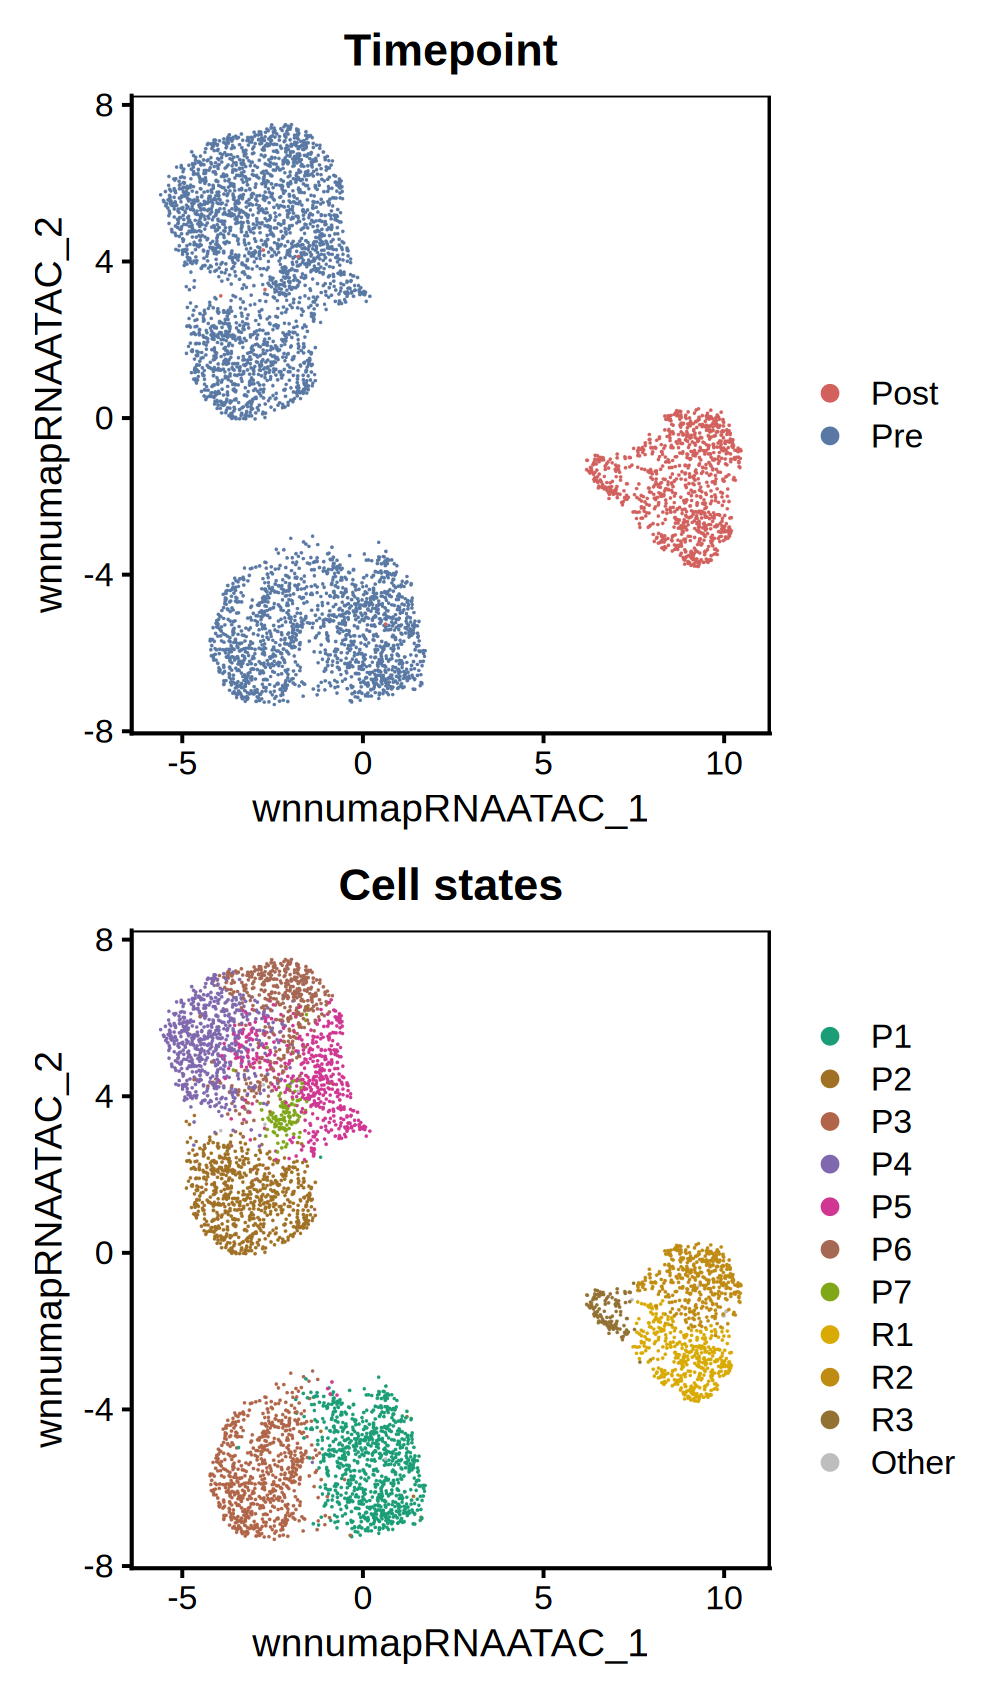

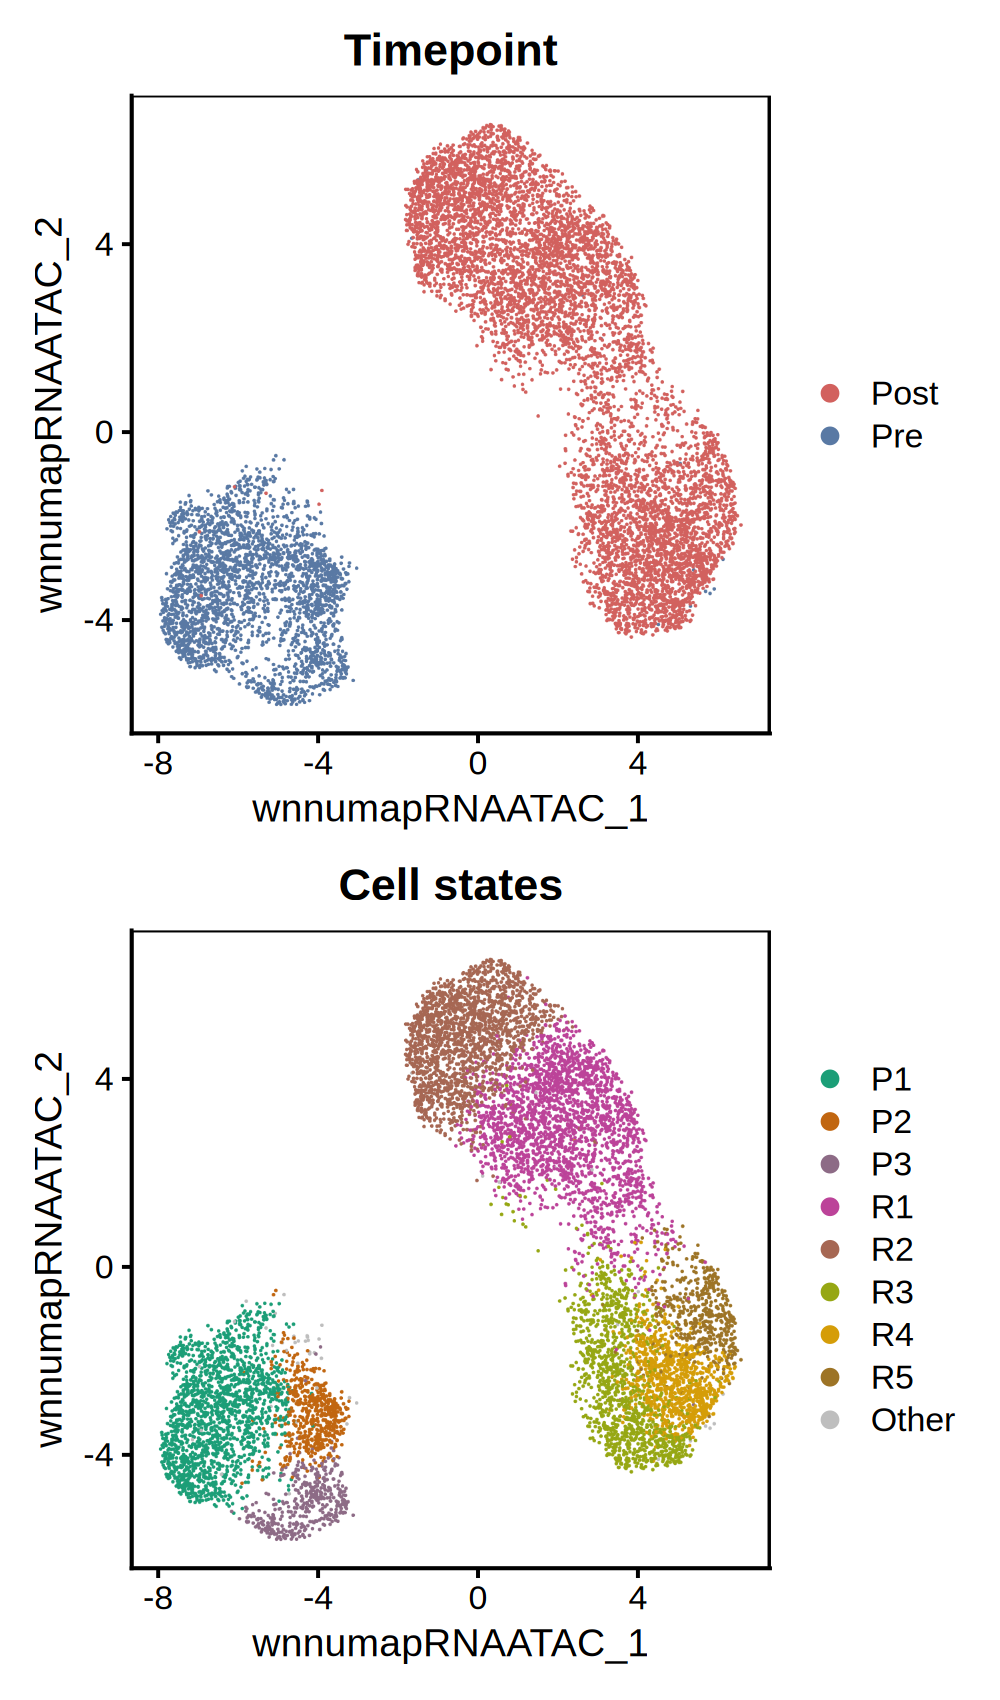

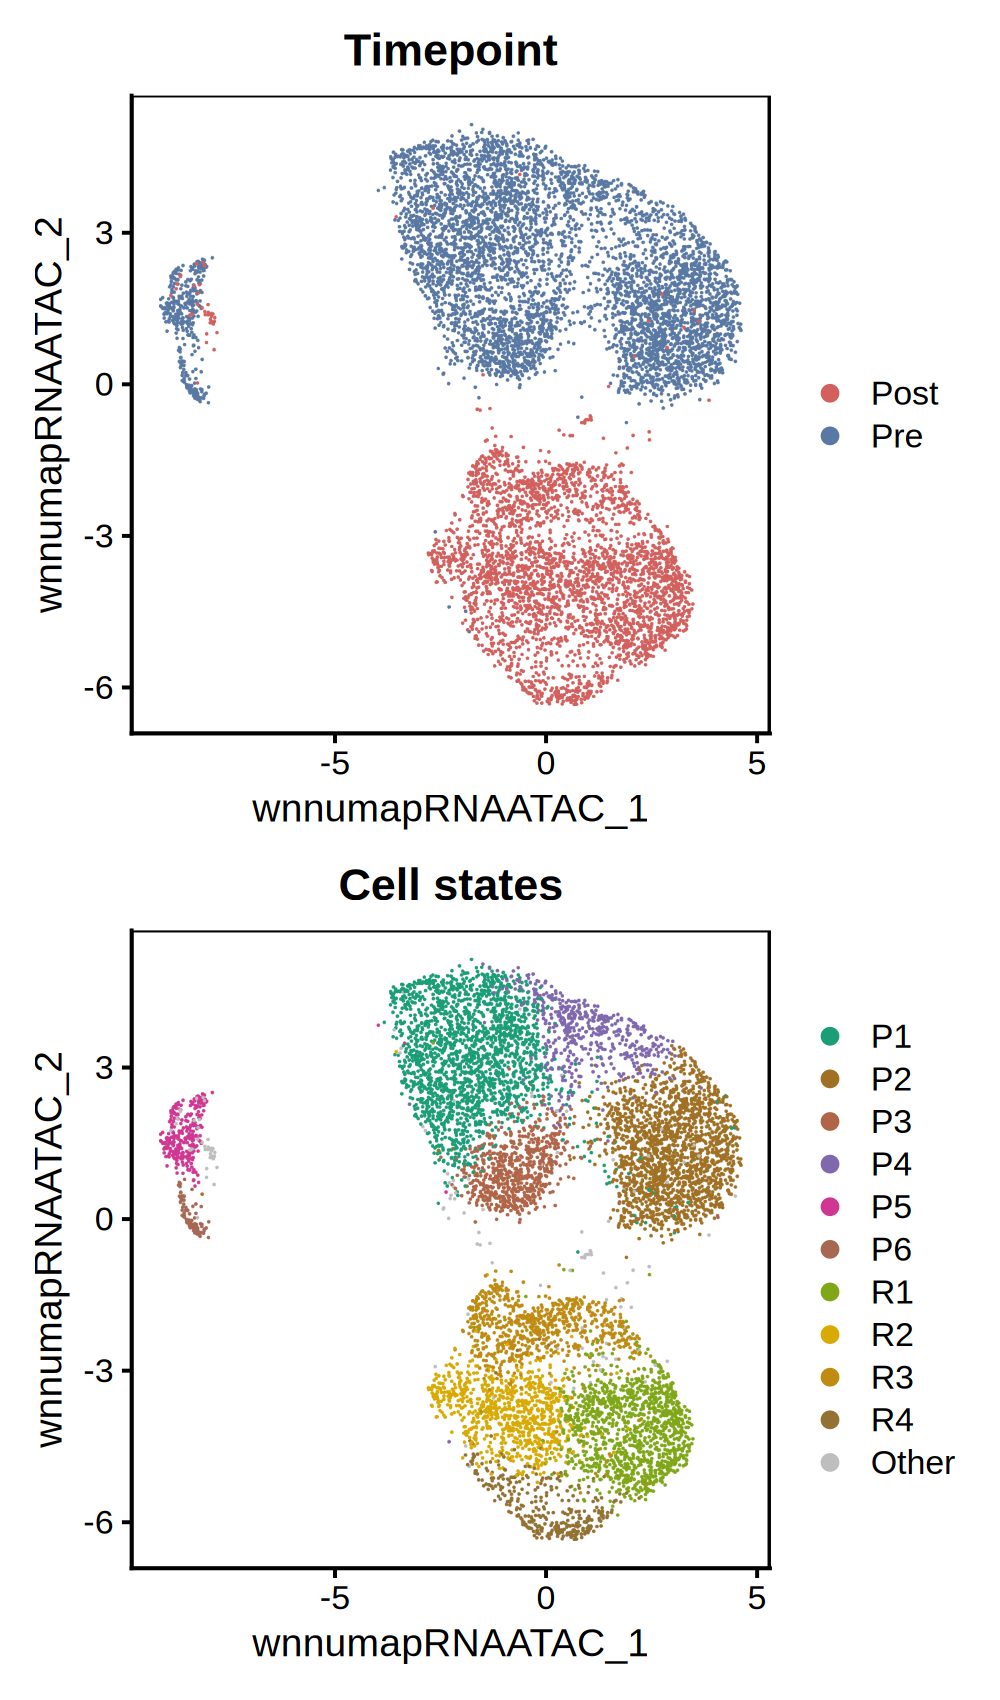

In [6]:
# Generate UMAP plots for all donors
options(repr.plot.width = 5, repr.plot.height = 8.5, repr.plot.res = 200)

pal_timepoint = c('Pre' = '#5979A4', 'Post' = '#D2615E')
raster_dpi = 300

for (donor in donors) {
    seu = seu_list_clustered[[donor]]
    
    p1 = DimPlot(seu, group.by = 'timepoint_label', pt.size = 0.5, stroke = 0, cols = pal_timepoint) + 
        ggtitle('Timepoint')
    
    # Get states and put "Other" last
    states = unique(seu@meta.data$cluster_label)
    states = c(sort(states[states != 'Other']), 'Other')
    states = states[states %in% unique(seu@meta.data$cluster_label)]
    
    # Set factor levels to control legend order
    seu@meta.data$cluster_label = factor(seu@meta.data$cluster_label, levels = states)
    
    pal_clusters = make_named_brewer_pal(length(states), labels = states, pal = 'Dark2')
    pal_clusters['Other'] = 'gray'
    
    p2 = DimPlot(seu, group.by = 'cluster_label', pt.size = 0.5, stroke = 0, label = F, cols = pal_clusters) + 
        theme(legend.position = "right") + 
        ggtitle('Cell states')
    
    p1 = ggrastr::rasterize(p1, layers = 'Point', dpi = raster_dpi)
    p2 = ggrastr::rasterize(p2, layers = 'Point', dpi = raster_dpi)
    
    panel = wrap_plots(p1, p2, ncol = 1) + plot_layout(guides = 'keep') &
        theme_transparent &
        theme(panel.border = element_rect(linewidth = 0.5, fill = NA, color = 'black'))
    
    print(panel)
    ggsave(glue('outputs/{donor}_cell_state_umap.pdf'), panel, width = 5, height = 8.5)
}

## Identify markers

In [3]:
seu_list_clustered = mclapply(
    donors,
    mc.cores = 3,
    function(donor) {
        readRDS(glue('../../../mm_analysis/seurat/{donor}_tumor_clustered.rds'))
    }
) %>% setNames(donors)

In [4]:
# Identify markers for all donors
markers_all = lapply(
    donors,
    function(donor) {
        message(glue('Finding markers for {donor}'))
        seu = seu_list_clustered[[donor]]
        
        # Get cluster dictionary for downstream use
        cluster_dict = seu@meta.data %>% 
            filter(cluster_label != 'Other') %>% 
            {setNames(.$cluster_label, rownames(.))}

        states = sort(unique(cluster_dict))
        
        # Find markers
        markers_rna = mclapply(
            states,
            mc.cores = 5,
            function(state) {
                FindMarkers(seu, assay = 'RNA', group.by = 'cluster_label', only.pos = T, test.use = 'wilcox', ident.1 = state) %>%
                    mutate(cluster = state) %>% tibble::rownames_to_column('gene')
            }
        ) %>% bind_rows()
        
        markers_atac = mclapply(
            states,
            mc.cores = 5,
            function(state) {
                FindMarkers(seu, assay = 'CHROMVAR', group.by = 'cluster_label', only.pos = T, test.use = 'wilcox', ident.1 = state) %>%
                    mutate(cluster = state) %>% tibble::rownames_to_column('gene')
            }
        ) %>% bind_rows()
        
        # Process markers
        marker_dat_rna = get_marker_dat(markers_rna, states, cluster_dict, GetAssayData(seu[['RNA']]))
        marker_dat_atac = get_marker_dat(markers_atac, states, cluster_dict, GetAssayData(seu[['CHROMVAR']]))
        
        return(list(
            marker_dat_rna = marker_dat_rna,
            marker_dat_atac = marker_dat_atac,
            states = states,
            cluster_dict = cluster_dict
        ))
    }
) %>% setNames(donors)

Finding markers for MM_BB094



R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


Finding markers for MM_BB121

Finding markers for MM_BB122



# BB094

In [5]:
# Get preprocessed results
donor = 'MM_BB094'
seu = seu_list_clustered[[donor]]

# Retrieve pre-computed markers
marker_dat_rna = markers_all[[donor]]$marker_dat_rna
marker_dat_atac = markers_all[[donor]]$marker_dat_atac
cluster_dict = markers_all[[donor]]$cluster_dict
states = markers_all[[donor]]$states

In [13]:
marker_dat_atac$top_markers %>% fwrite(glue('outputs/top_markers_atac_{donor}.csv'))
marker_dat_rna$top_markers %>% fwrite(glue('outputs/top_markers_rna_{donor}.csv'))

In [7]:
rna_markers <- list(
	`0(P)` = c("DCC", "PTP4A3", "AGR2"),
	`1(P)` = c("FCER2", "DACH1", "GALNT13"),
	`2(P)` = c("IGLC5", "CTSW", "SLC22A17"),
	`3(P)` = c("CXCL10", "IFI27", "AZGP1"),
	`4(P)` = c("ABCG1", "ANXA1", "RELN"),
	`5(P)` = c("IL6", "CCL4L2", "RPH3A"),
	`6(R)` = c("NOTCH3", "NES", "SLC17A8"),
	`7(R)` = c("NNMT", "ACKR2", "APOL4"),
	`8(R)` = c("CD34", "EGFL7", "SLIT3"),
	`9(P)` = c("MKI67", "TICRR", "E2F8")
)

atac_markers <- list(
	`1(P)` = c("PITX2", "ESR1", "NFKB1"),
	`0(P)` = c("NFIB", "POU2F3", "TCF3"),
	`2(P)` = c("EGR2", "MEF2D", "EGR1"),
	`5(P)` = c("ESRRA", "SOX8", "NKX2-2"),
	`4(P)` = c("NFYC", "RFX1", "KLF13"),
	`3(P)` = c("IRF4", "IRF7", "STAT1::STAT2"),
	`9(P)` = c("FOSL2::JUNB", "MAFK", "KLF2"),
	`6(R)` = c("CTCF", "EBF1", "ZIC1"),
	`7(R)` = c("DUX4", "KLF15", "NFIA"),
	`8(R)` = c("NFYA", "BHLHE41", "ARNT2")
)

highlight_rna = unlist(rna_markers)
highlight_atac = unlist(atac_markers)

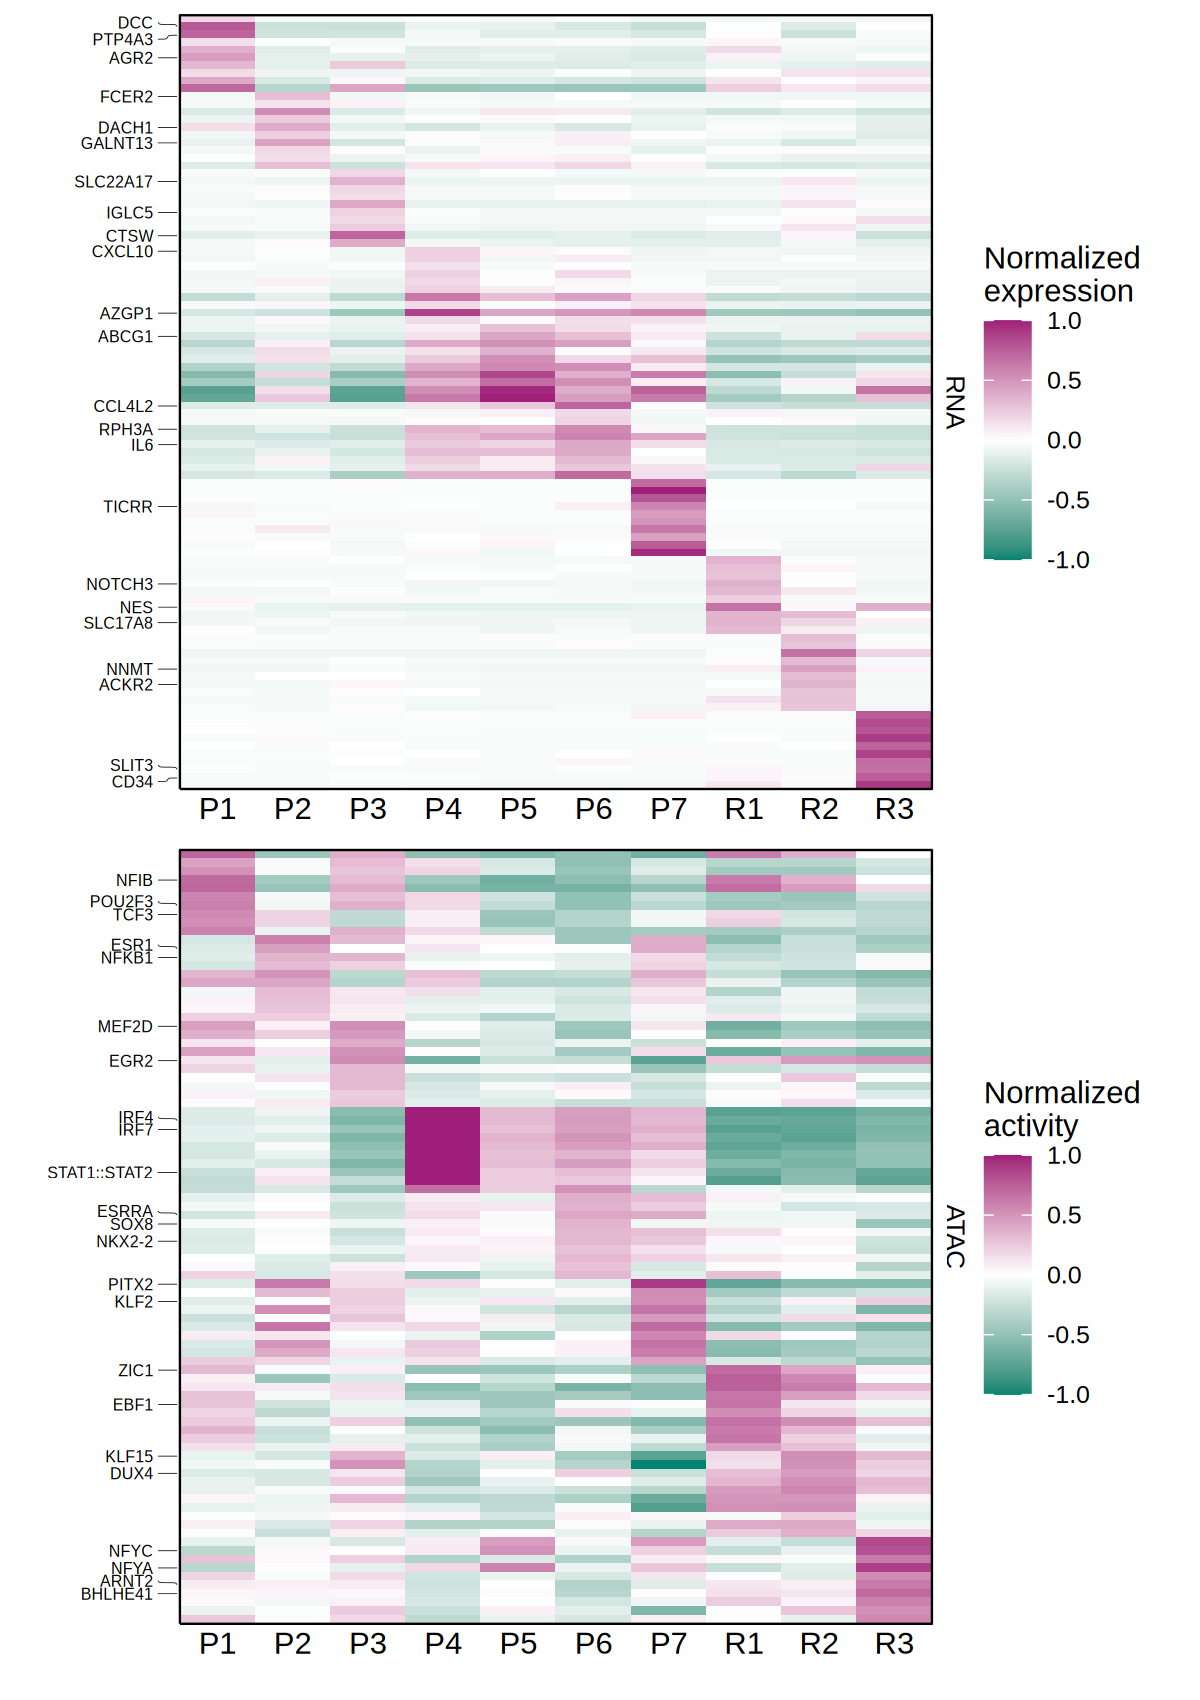

In [200]:
options(repr.plot.width = 6, repr.plot.height = 8.5, repr.plot.res = 200)
R.utils::sourceDirectory(glue('../../R'))

p_rna = plot_marker_heatmap(
    marker_dat_rna$df_z, states, highlight = highlight_rna,
    y_title = 'RNA'
)

p_atac = plot_marker_heatmap(
    marker_dat_atac$df_z, states, highlight = highlight_atac,
    y_title = 'ATAC', legend_title = 'Normalized\nactivity'
)

panel = (p_rna / p_atac)

panel

ggsave(glue('outputs/{donor}_rna_atac_markers.pdf'), panel, width = 6, height = 8.5)

## Run PATH

In [6]:
donor = 'MM_BB094'
seu = seu_list_clustered[[donor]]

phy_trim = phy_trim_all[[donor]]

cluster_dict = seu@meta.data %>% filter(cluster_label != 'Other') %>% {setNames(.$cluster_label, rownames(.))}

path_res_mt = run_path(phy_trim, cluster_dict)
tmat = run_path_inf(phy_trim, cluster_dict)$Pt

state_order = target_proximity(tmat, target = str_subset(colnames(tmat), 'R'))$state %>% rev

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“`guide_colourbar()` needs continuous scales.”
Warning message:
“`guide_colourbar()` needs continuous scales.”
Warning message:
“`guide_colourbar()` needs continuous scales.”
Warning message:
“`guide_colourbar()` needs continuous scales.”
Warning message:
“`guide_colourbar()` needs continuous scales.”
Warning message:
“`guide_colourbar()` needs continuous scales.”


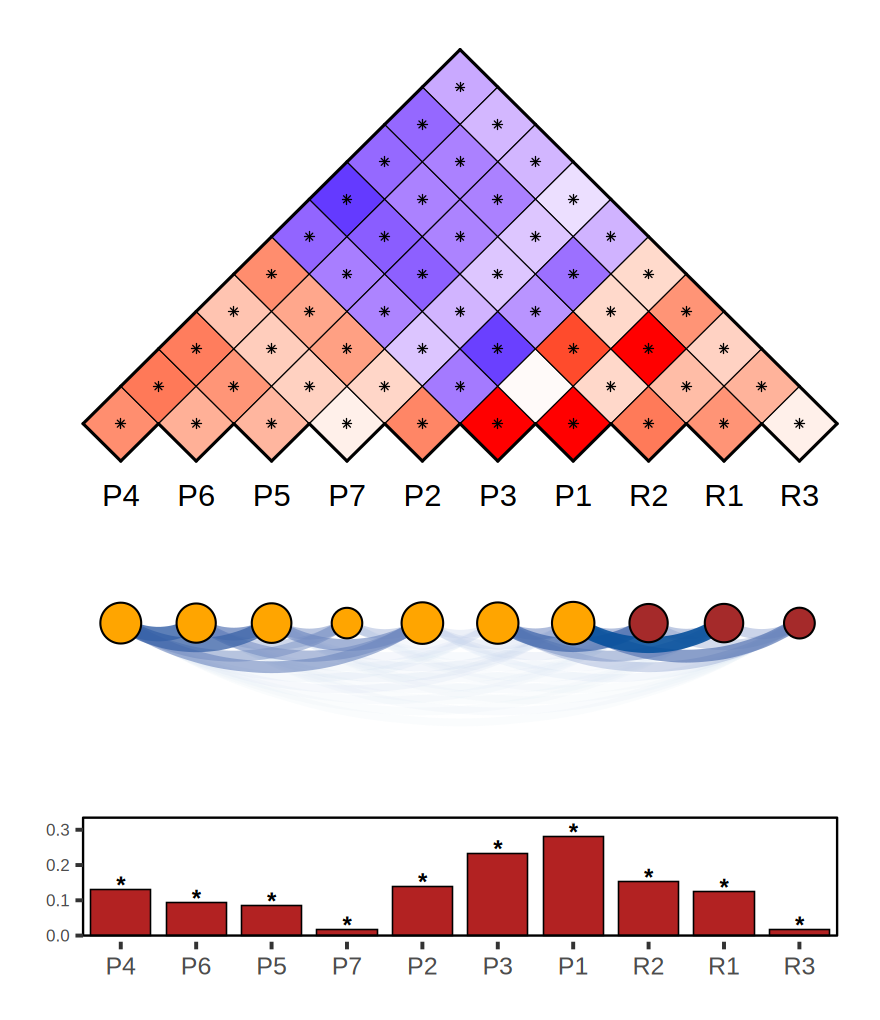

In [7]:
options(repr.plot.width = 4.4, repr.plot.height = 5.1, repr.plot.res = 200)
R.utils::sourceDirectory(glue('../../R'))

node_fill_dict = setNames(ifelse(str_detect(state_order, 'P'), 'orange', 'brown'), state_order)
node_size_dict = log(c(table(cluster_dict)))

p = plot_coupling_panel(
    path_res_mt, tmat, state_order, linewidth_range = c(1,2),
    node_fill_map = node_fill_dict, node_size_map = node_size_dict,
    limits = c(-50,50), 
    self_coupling_limits = c(0,0.35),
    statistic = 'z',
    mark_signif = T,
    panel_spacing = 0.3
) &
guides(
    fill = guide_colourbar(
        title.position = "top",
        title.hjust = 1,
        label.position = "left",
        label.hjust = 1,
        title = "Coupling\nZ-score"
    ),
    colour = guide_colourbar(
        title.position = "top",
        title.hjust = 1,
        label.position = "left",
        label.hjust = 1,
        title = 'Transition\nStrength'
    )
)

leg = cowplot::get_legend(p)
p_leg = cowplot::ggdraw(leg)
p = p & theme(legend.position = 'none', legend) & theme_transparent

p

ggsave(glue('outputs/{donor}_coupling_panel.pdf'), p, width = 4.4, height = 5.1)
ggsave(glue('outputs/{donor}_coupling_panel_legend.pdf'), p_leg, width = 1, height = 4)

In [40]:
path_res_mt %>% filter(state_x == state_y) %>% arrange(-cor)

state_x,state_y,z,cor,lower,upper,p,q
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P1,P1,61.617467,0.28158416,0.272620520,0.29054780,0.000000e+00,0.000000e+00
P3,P3,51.173683,0.23379213,0.224829590,0.24275467,0.000000e+00,0.000000e+00
R2,R2,33.536182,0.15306466,0.144106478,0.16202284,1.431700e-246,7.953887e-246
P2,P2,30.709139,0.14022347,0.131260183,0.14918676,4.297703e-207,1.481967e-206
P4,P4,28.791025,0.13144118,0.122478595,0.14040376,2.778404e-182,8.419407e-182
R1,R1,27.453098,0.12524456,0.116287580,0.13420153,6.380419e-166,1.679058e-165
P6,P6,20.594073,0.09393211,0.084971985,0.10289224,3.101682e-94,5.441547e-94
P5,P5,18.901483,0.08619978,0.077239081,0.09516047,1.108919e-79,1.848199e-79
P7,P7,3.994549,0.01798180,0.009053223,0.02691037,6.481742e-05,6.682208e-05


## Cell cycle

In [6]:
s.genes <- cc.genes$s.genes
g2m.genes <- cc.genes$g2m.gene
DefaultAssay(seu) = 'RNA'
seu <- CellCycleScoring(seu, s.features = s.genes, g2m.features = g2m.genes, set.ident = TRUE)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The following features are not present in the object: MLF1IP, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: FAM64A, HN1, not searching for symbol synonyms”


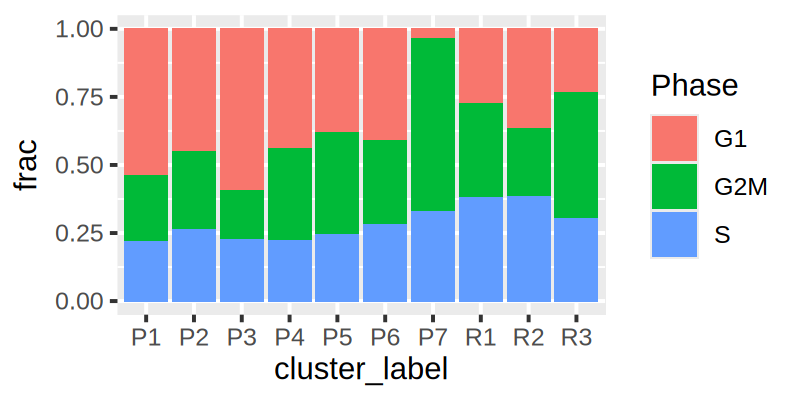

In [9]:
options(repr.plot.width = 4, repr.plot.height = 2, repr.plot.res = 200)

seu@meta.data %>% 
filter(cluster_label != 'Other') %>%
count(cluster_label, Phase) %>%
group_by(cluster_label) %>%
mutate(frac = n/sum(n)) %>%
ggplot(
    aes(x = cluster_label, y = frac, fill = Phase)
) +
geom_col(position = position_stack())

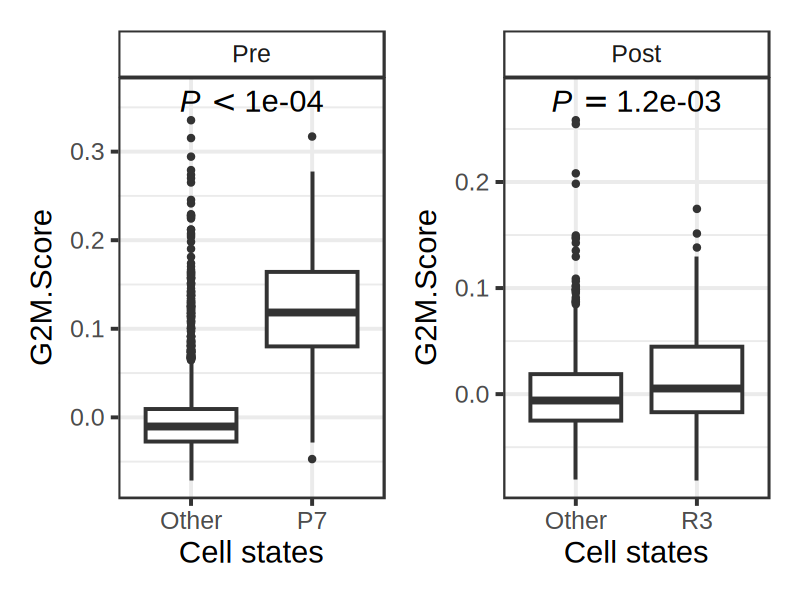

In [145]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 200)

p_thresh <- 1e-4
digits_after_decimal <- 1

fmt_sci <- function(x, digits_after_decimal = 4) {
	formatC(x, format = "e", digits = digits_after_decimal)
}

fmt_thresh <- function(thresh) {
	formatC(thresh, format = "e", digits = 0)
}

make_p_label_plotmath <- function(p, thresh, digits_after_decimal = 4) {
	# returns a plotmath expression string for parse=TRUE
	if (is.na(p)) return(NA_character_)
	if (p < thresh) {
		paste0("italic(P) < '", fmt_thresh(thresh), "'")
	} else {
		paste0("italic(P) == '", fmt_sci(p, digits_after_decimal), "'")
	}
}

seu@meta.data %>%
	as.data.frame() %>%
	dplyr::filter(cluster_label != "Other", !is.na(G2M.Score)) %>%
	dplyr::mutate(comp_group = ifelse(cluster_label %in% c("R3","P7"), cluster_label, "Other")) %>%
	split(.$timepoint) %>%
	lapply(function(df) {
		pv <- wilcox.test(G2M.Score ~ comp_group, data = df)$p.value
		p_lab <- make_p_label_plotmath(pv, p_thresh, digits_after_decimal)

		ypos <- max(df$G2M.Score, na.rm = TRUE)

		ggplot(df, aes(x = comp_group, y = G2M.Score)) +
			geom_boxplot(outlier.size = 0.5) +
			facet_wrap(~timepoint_label, scales = "free_x") +
			theme_bw() +
			theme(strip.background = element_rect(fill = NA)) +
			annotate(
				"text",
				x = 1.5,
				y = ypos,
				label = p_lab,
				parse = TRUE,
				hjust = 0.5,
				vjust = -0.4
			) +
			scale_y_continuous(expand = expansion(mult = c(0.05, 0.12))) +
			xlab("Cell states") +
			theme_transparent
	}) %>%
	wrap_plots()

# BB121

## Identify markers

In [203]:
# Get preprocessed results
donor = 'MM_BB121'
seu = seu_list_clustered[[donor]]

# Retrieve pre-computed markers
marker_dat_rna = markers_all[[donor]]$marker_dat_rna
marker_dat_atac = markers_all[[donor]]$marker_dat_atac
cluster_dict = markers_all[[donor]]$cluster_dict
states = markers_all[[donor]]$states

In [204]:
rna_markers <- list(
	`2(P)` = c("MNDA", "FCER1G", "GZMM"),
	`7(P)` = c("VNN2", "FCER1A", "PRDM14"),
	`5(P)` = c("COL4A6", "CTNNA2", "GINS1"),
	`8(P)` = c("IGKV3-15", "IGHV3-30", "IGLV1-44"),
	`0(R)` = c("CCDC6", "GABPB1", "NFATC1"),
	`3(R)` = c("NMB", "PGR", "CAMK2N2"),
	`1(R)` = c("FAR2", "BDNF", "ZBTB16"),
	`4(R)` = c("RPS28", "COX7C", "IFITM1"),
	`6(R)` = c("CCL4", "CCL3", "ID2")
)

cluster_labels <- c(
	`2(P)` = "immune / cytotoxic-like PCs (MNDA+/GZMM+)",
	`7(P)` = "VNN2/FCER1A/PRDM14+ signaling / stem-like PCs",
	`5(P)` = "ECM / adhesion & cycling PCs (COL4A6+/CTNNA2+)",
	`8(P)` = "Ig-variable–high clone (IGKV/IGHV/IGLV+)",
	`0(R)` = "baseline NFATC1/GABPB1+ relapse PCs",
	`3(R)` = "NMB/PGR/CAMK2N2+ signaling relapse PCs",
	`1(R)` = "metabolic / BDNF / ZBTB16+ relapse PCs",
	`4(R)` = "high translation / mito + IFITM1+ relapse PCs",
	`6(R)` = "CCL3/CCL4 chemokine-high relapse PCs"
)

highlight_rna = unlist(rna_markers)
# highlight_atac = unlist(atac_markers)

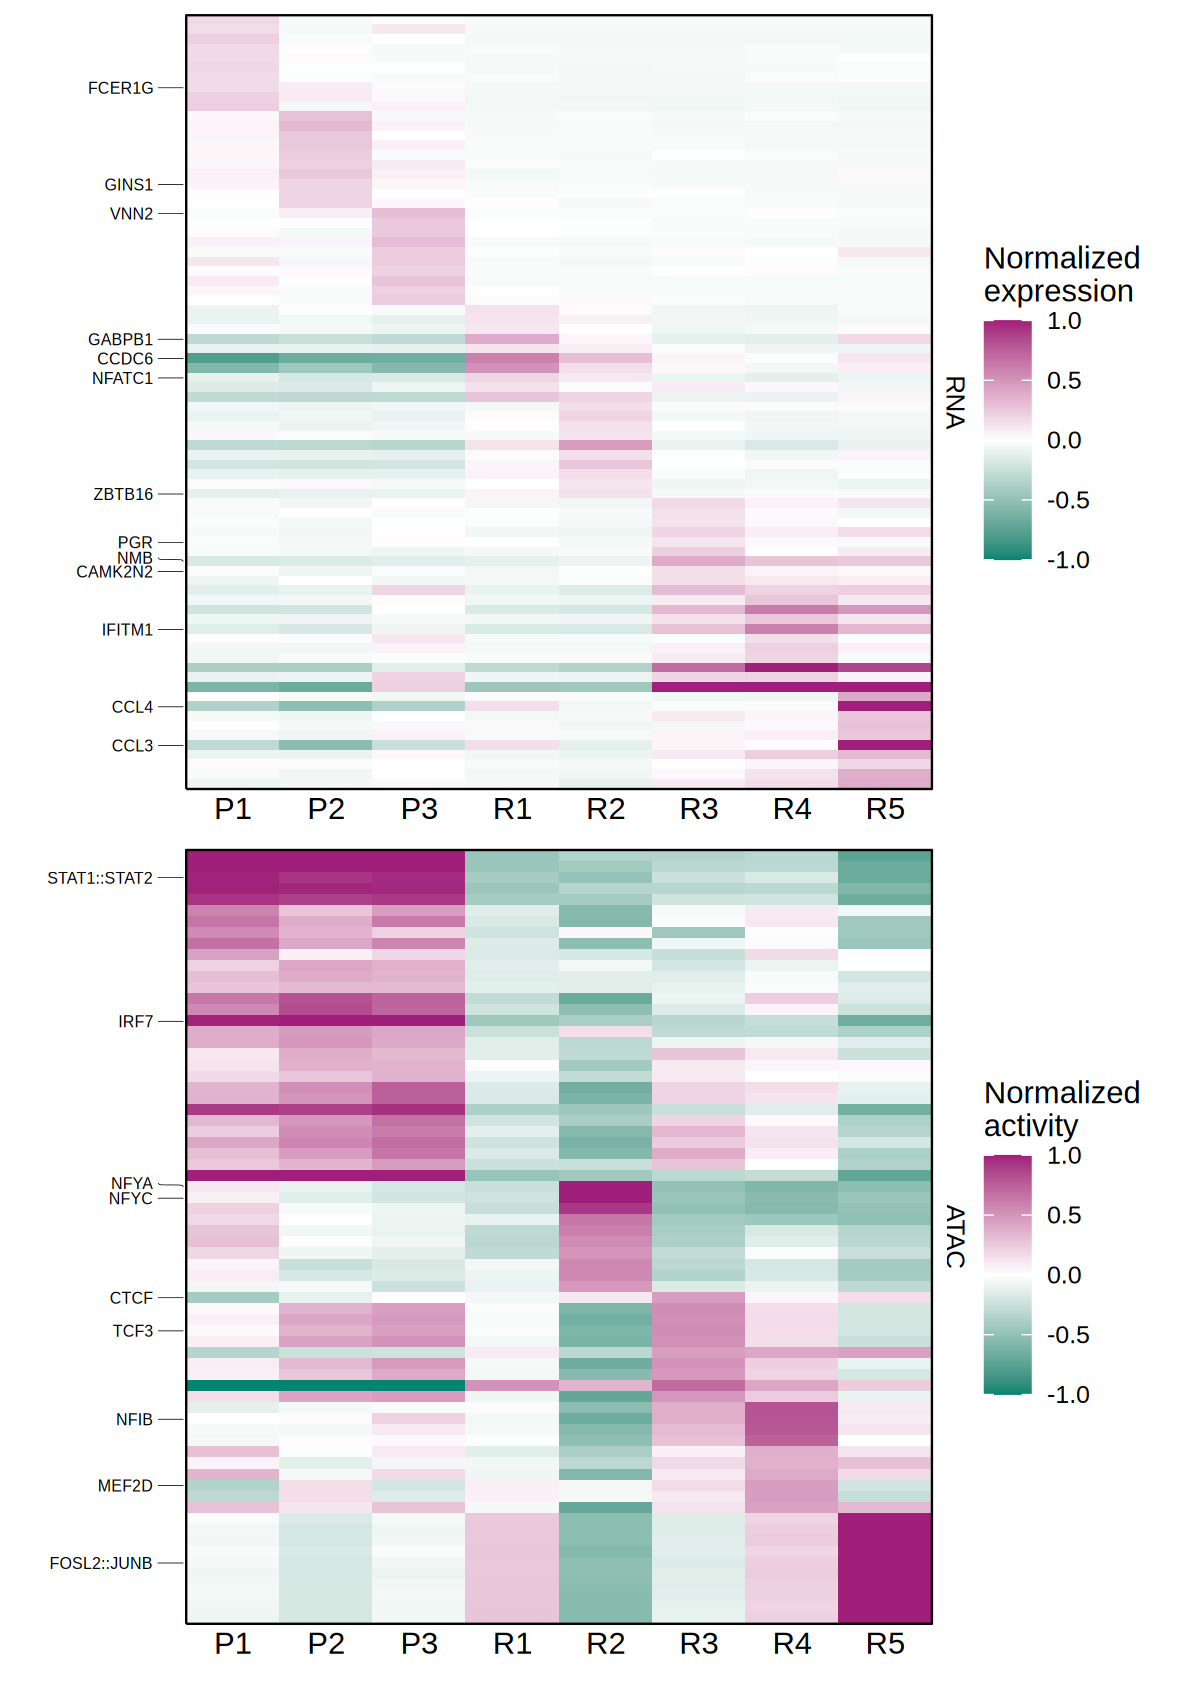

In [205]:
options(repr.plot.width = 6, repr.plot.height = 8.5, repr.plot.res = 200)
R.utils::sourceDirectory(glue('../../R'))

p_rna = plot_marker_heatmap(
    marker_dat_rna$df_z, states, highlight = highlight_rna,
    y_title = 'RNA'
)

p_atac = plot_marker_heatmap(
    marker_dat_atac$df_z, states, highlight = highlight_atac,
    y_title = 'ATAC', legend_title = 'Normalized\nactivity'
)

panel = (p_rna / p_atac)

panel

ggsave(glue('outputs/{donor}_rna_atac_markers.pdf'), panel, width = 6, height = 8.5)

## Run PATH

In [240]:
# Get preprocessed results
donor = 'MM_BB121'
seu = seu_list_clustered[[donor]]

phy_trim = phy_trim_all[[donor]]

cluster_dict = seu@meta.data %>% filter(cluster_label != 'Other') %>% {setNames(.$cluster_label, rownames(.))}

path_res_mt = run_path(phy_trim, cluster_dict)
tmat = run_path_inf(phy_trim, cluster_dict)$Pt

state_order = target_proximity(tmat, target = str_subset(colnames(tmat), 'R'))$state %>% rev

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


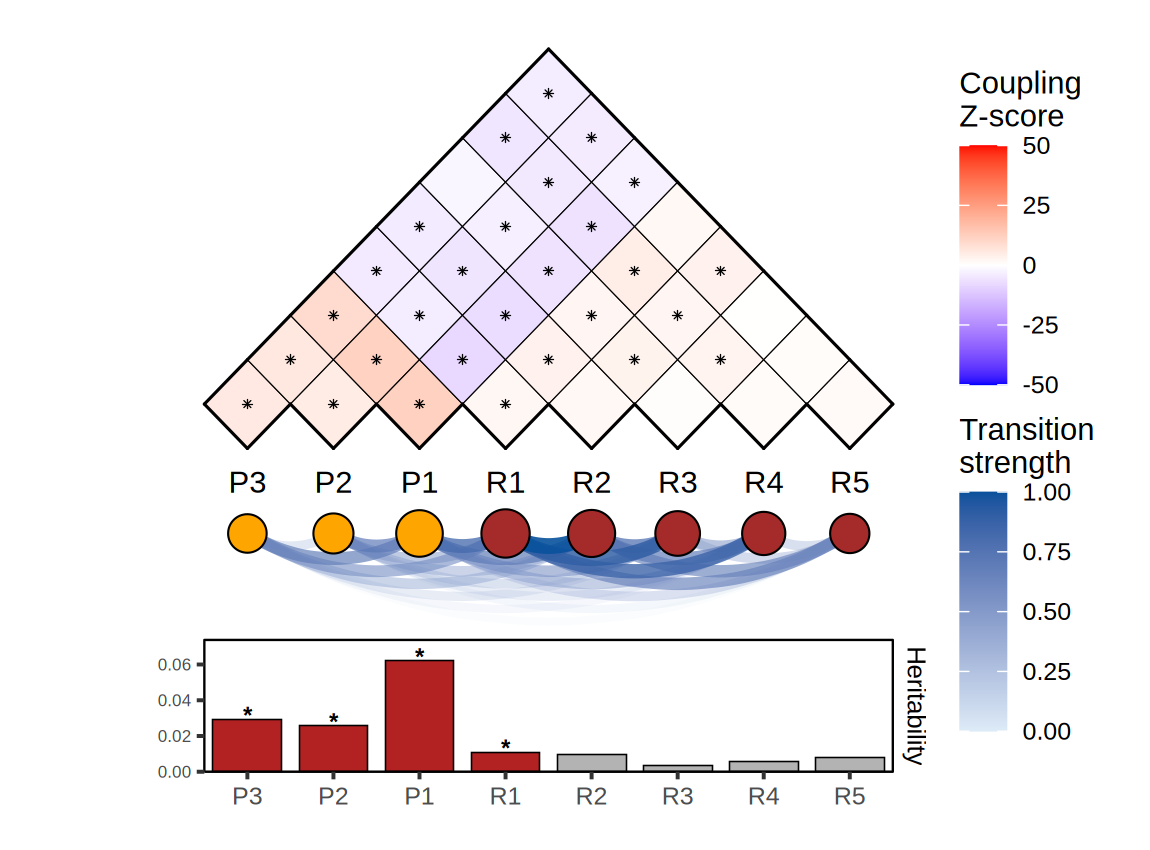

In [241]:
options(repr.plot.width = 5.75, repr.plot.height = 4.25, repr.plot.res = 200)
R.utils::sourceDirectory(glue('../../R'))

node_fill_dict = setNames(ifelse(str_detect(state_order, 'P'), 'orange', 'brown'), state_order)
node_size_dict = log(c(table(cluster_dict)))

p = plot_coupling_panel(
    path_res_mt, tmat, state_order, linewidth_range = c(1,2),
    node_fill_map = node_fill_dict, node_size_map = node_size_dict,
    limits = c(-50,50), 
    # self_coupling_limits = c(0,0.35),
    statistic = 'z',
    mark_signif = T,
) & theme_transparent

p

ggsave(glue('outputs/{donor}_coupling_panel.pdf'), p, width = 5.75, height = 4.25)

# BB122

## Run PATH

In [236]:
donor = 'MM_BB122'
# Get preprocessed results
seu = seu_list_clustered[[donor]]

phy_trim = phy_trim_all[[donor]]

cluster_dict = seu@meta.data %>% filter(cluster_label != 'Other') %>% {setNames(.$cluster_label, rownames(.))}

path_res_mt = run_path(phy_trim, cluster_dict)
tmat = run_path_inf(phy_trim, cluster_dict)$Pt

state_order = target_proximity(tmat, target = str_subset(colnames(tmat), 'R'))$state %>% rev

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


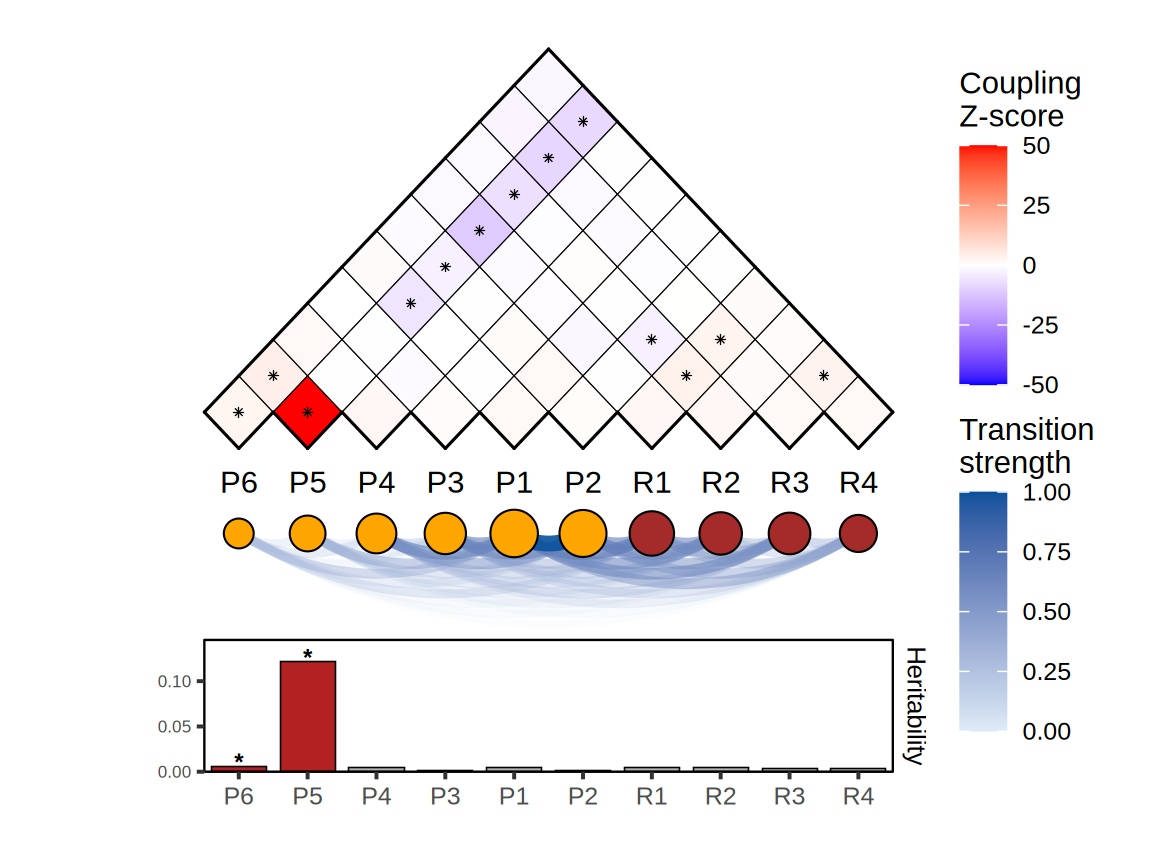

In [ ]:
options(repr.plot.width = 5.75, repr.plot.height = 4.25, repr.plot.res = 200)
R.utils::sourceDirectory(glue('../../R'))

node_fill_dict = setNames(ifelse(str_detect(state_order, 'P'), 'orange', 'brown'), state_order)
node_size_dict = log(c(table(cluster_dict)))

p = plot_coupling_panel(
    path_res_mt, tmat, state_order, linewidth_range = c(1,2),
    node_fill_map = node_fill_dict, node_size_map = node_size_dict,
    limits = c(-50,50), 
    # self_coupling_limits = c(0,0.35),
    statistic = 'z',
    mark_signif = T,
) & theme_transparent

p

ggsave(glue('outputs/{donor}_coupling_panel.pdf'), p, width = 5.75, height = 4.25)

## Identify markers

In [73]:
markers_rna = mclapply(
    state_order,
    mc.cores = 5,
    function(state) {
        FindMarkers(seu, assay = 'RNA', group.by = 'cluster_label', only.pos = T, test.use = 'wilcox', ident.1 = state) %>%
            mutate(cluster = state) %>% tibble::rownames_to_column('gene')
    }
) %>% bind_rows()

markers_atac = mclapply(
    state_order,
    mc.cores = 5,
    function(state) {
        FindMarkers(seu, assay = 'CHROMVAR', group.by = 'cluster_label', only.pos = T, test.use = 'wilcox', ident.1 = state) %>%
            mutate(cluster = state) %>% tibble::rownames_to_column('gene')
    }
) %>% bind_rows()

In [74]:
marker_dat_rna = get_marker_dat(markers_rna, state_order, cluster_dict, GetAssayData(seu[['RNA']]))
marker_dat_atac = get_marker_dat(markers_atac, state_order, cluster_dict, GetAssayData(seu[['CHROMVAR']]))

In [322]:
# marker_dat_rna$top_markers %>% fwrite(glue('top_markers_rna_{donor}.csv'))
# marker_dat_atac$top_markers %>% fwrite(glue('top_markers_atac_{donor}.csv'))

In [75]:
rna_markers <- list(
	`0(P)` = c("IGLV3-10", "PLCB4", "PIEZO2"),
	`1(P)` = c("IGLC1", "IFITM1", "IFI27"),
	`5(P)` = c("GRIK4", "ITGA8", "LRP8"),
	`6(P)` = c("XAF1", "GBP4", "LAG3"),
	`8(P)` = c("COL4A5", "ME1", "ADAM28"),
	`9(P)` = c("SLC7A11", "KRT7", "CAVIN3"),
	`2(R)` = c("TXNIP", "GLUL", "ESAM"),
	`3(R)` = c("CALB1", "PDGFD", "CD24"),
	`4(R)` = c("TRIM5", "IL1R2", "NFIA"),
	`7(R)` = c("KIF18A", "PTGDS", "CHAD")
)

atac_markers = list(
	`0(P)` = c("BACH1", "FOSL1", "JUNB"),          # AP-1 / BACH1 program
	`1(P)` = c("IRF7", "RARA", "GFI1"),           # IFN / retinoic / plasma TFs
	`6(P)` = c("RELA", "NFKB1", "NFKB2"),         # canonical NF-κB module
	`5(P)` = c("CTCF", "IRF4", "FOXC1"),          # architectural + IRF4
	`8(P)` = c("FOS", "ATF3", "CREB1"),           # AP-1 / ATF / CREB stress
	`9(P)` = c("RUNX2", "MEF2C", "KLF2"),         # RUNX/MEF2/KLF lineage module
	`4(R)` = c("YY1", "NRF1", "E2F2"),            # YY1/NRF1/E2F proliferation-mito
	`3(R)` = c("NR3C1", "NR3C2", "ELF1"),         # glucocorticoid + ETS
	`2(R)` = c("ETV4", "IKZF1", "GABPA"),         # ETS + IKZF1
	`7(R)` = c("ETS2", "ELK4", "ZBTB7A")          # ETS/ZBTB7A relapse module
)

state_labels <- c(
	`0(P)` = "signaling-rich LC PCs",
	`1(P)` = "IFN-high PCs",
	`5(P)` = "adhesion/receptor PCs",
	`6(P)` = "stressed IFN/lag3 PCs",
	`8(P)` = "ECM/metabolic PCs",
	`9(P)` = "SLC7A11+ redox PCs",
	`2(R)` = "metabolic ESAM+ relapse",
	`3(R)` = "CD24/PDGFD relapse",
	`4(R)` = "IL1R2/NFIA relapse",
	`7(R)` = "proliferative/ECM"
)

highlight_rna = unlist(rna_markers)
highlight_atac = unlist(atac_markers)